# Shot Clock Debug

In [309]:
import pandas as pd

# Use 2024-25 season data (matches the raw data we're analyzing)
df = pd.read_csv('enriched_data/nbastatsv3_2024_enriched_shots.csv')

print(f"Loaded {len(df):,} shots")
print(f"Sample gameIds: {df['gameId'].unique()[:5]}")

print(f"\nMedian SHOT_CLOCK_APPROX: {df['SHOT_CLOCK_APPROX'].median():.1f}")
print(f"Mean SHOT_CLOCK_APPROX: {df['SHOT_CLOCK_APPROX'].mean():.1f}")

print()
print("=== By Shot Result ===")
made = df[df['shotResult'].str.upper() == 'MADE']
missed = df[df['shotResult'].str.upper() == 'MISSED']

print(f"MADE shots   - Median: {made['SHOT_CLOCK_APPROX'].median():.1f}, Mean: {made['SHOT_CLOCK_APPROX'].mean():.1f}")
print(f"MISSED shots - Median: {missed['SHOT_CLOCK_APPROX'].median():.1f}, Mean: {missed['SHOT_CLOCK_APPROX'].mean():.1f}")

Loaded 219,528 shots
Sample gameIds: [22400001 22400002 22400003 22400004 22400005]

Median SHOT_CLOCK_APPROX: 11.0
Mean SHOT_CLOCK_APPROX: 11.2

=== By Shot Result ===
MADE shots   - Median: 12.0, Mean: 11.5
MISSED shots - Median: 11.0, Mean: 10.9


In [310]:
# Investigate the 0-second spike - look at specific examples
zero_shots = df[df['SHOT_CLOCK_APPROX'] <= 1]
print(f"Shots with SHOT_CLOCK_APPROX <= 1 second: {len(zero_shots):,} ({len(zero_shots)/len(df)*100:.1f}%)")
print(f"  Made: {len(zero_shots[zero_shots['shotResult'].str.upper() == 'MADE']):,}")
print(f"  Missed: {len(zero_shots[zero_shots['shotResult'].str.upper() == 'MISSED']):,}")

print("\n=== SHOT_CLOCK_SOURCE for 0-1 second shots ===")
print(zero_shots['SHOT_CLOCK_SOURCE'].value_counts().head(10))

# Look at made_fg resets specifically - these should be from the OTHER team's made shot
made_fg_resets = zero_shots[zero_shots['SHOT_CLOCK_SOURCE'] == 'made_fg(24)']
print(f"\n=== Shots using made_fg(24) as reset: {len(made_fg_resets):,} ===")
print("These shots have 0 seconds because they're at same ABS_TIME as opponent's made shot")
print("\nSample rows:")
print(made_fg_resets[['gameId', 'period', 'clock', 'ABS_TIME', 'actionNumber', 'teamTricode', 
                       'description', 'SHOT_CLOCK_APPROX', 'shotResult']].head(10).to_string())

Shots with SHOT_CLOCK_APPROX <= 1 second: 8,389 (3.8%)
  Made: 3,349
  Missed: 5,040

=== SHOT_CLOCK_SOURCE for 0-1 second shots ===
SHOT_CLOCK_SOURCE
made_fg(24)             4571
final_ft(24)             823
def_foul_14(14)          750
def_reb(24)              717
off_reb(14)              510
turnover(24)             454
period_start(24)         256
def_violation_14(14)      74
keep_clock(15)            53
jumpball(24)              53
Name: count, dtype: int64

=== Shots using made_fg(24) as reset: 4,571 ===
These shots have 0 seconds because they're at same ABS_TIME as opponent's made shot

Sample rows:
       gameId  period        clock  ABS_TIME  actionNumber teamTricode                                                  description  SHOT_CLOCK_APPROX shotResult
204  22400002       4  PT08M53.00S      2347           528         DET  Ivey 9' Driving Floating Jump Shot (12 PTS) (Beasley 1 AST)                0.0       Made
280  22400002       3  PT07M15.00S      1725           391    

In [311]:
# Investigate the 0-second spike
zero_shots = df[df['SHOT_CLOCK_APPROX'] <= 1]
print(f"Shots with SHOT_CLOCK_APPROX <= 1 second: {len(zero_shots):,} ({len(zero_shots)/len(df)*100:.1f}%)")
print(f"  Made: {len(zero_shots[zero_shots['shotResult'].str.upper() == 'MADE']):,}")
print(f"  Missed: {len(zero_shots[zero_shots['shotResult'].str.upper() == 'MISSED']):,}")

print("\n=== SHOT_CLOCK_SOURCE for 0-1 second shots ===")
print(zero_shots['SHOT_CLOCK_SOURCE'].value_counts().head(10))

print("\n=== Sample of 0-second shots ===")
print(zero_shots[['description', 'SHOT_CLOCK_APPROX', 'SHOT_CLOCK_SOURCE', 'shotResult']].head(20))

Shots with SHOT_CLOCK_APPROX <= 1 second: 8,389 (3.8%)
  Made: 3,349
  Missed: 5,040

=== SHOT_CLOCK_SOURCE for 0-1 second shots ===
SHOT_CLOCK_SOURCE
made_fg(24)             4571
final_ft(24)             823
def_foul_14(14)          750
def_reb(24)              717
off_reb(14)              510
turnover(24)             454
period_start(24)         256
def_violation_14(14)      74
keep_clock(15)            53
jumpball(24)              53
Name: count, dtype: int64

=== Sample of 0-second shots ===
                                           description  SHOT_CLOCK_APPROX  \
11              MISS Risacher 25' 3PT Pullup Jump Shot                0.0   
20                    MISS Johnson 16' Fadeaway Jumper                1.0   
102                 MISS Tatum 18' Step Back Jump Shot                0.0   
148  Hauser 24' 3PT Jump Shot (3 PTS) (Pritchard 2 ...                1.0   
176                        MISS Love 25' 3PT Jump Shot                1.0   
177       Love 28' 3PT Jump Shot (3 P

In [312]:
# Look at raw play-by-play for one specific game to understand event ordering
import pandas as pd
raw = pd.read_csv('raw_data/nbastatsv3_2024.csv')

# Pick first game
game = raw[raw['gameId'] == 22400001].copy()
game = game.sort_values(['period', 'actionNumber']).reset_index(drop=True)

# Show first 30 events
print("=== First 30 events of game 22400001 ===")
print(game[['actionNumber', 'clock', 'period', 'teamTricode', 'actionType', 'subType', 
            'description']].head(30).to_string())

=== First 30 events of game 22400001 ===
    actionNumber        clock  period teamTricode   actionType                          subType                                             description
0              2  PT12M00.00S       1         NaN       period                            start                       Start of 1st Period (7:11 PM EST)
1              4  PT12M00.00S       1         BOS    Jump Ball                              NaN            Jump Ball Horford vs. Capela: Tip to Wallace
2              7  PT11M43.00S       1         ATL  Missed Shot                        Jump Shot                         MISS Risacher 27' 3PT Jump Shot
3              7  PT11M43.00S       1         BOS          NaN                              NaN                                     Tatum BLOCK (1 BLK)
4              9  PT11M42.00S       1         ATL      Rebound                          Unknown                          Risacher REBOUND (Off:1 Def:0)
5             10  PT11M38.00S       1         A

In [313]:
# Check ABS_TIME calculation for these events
import re

def _abs_time(period, clock_iso):
    m = re.match(r"PT(\d+)M(\d+)\.\d+S", str(clock_iso))
    if not m:
        return None
    rem = int(m.group(1))*60 + int(m.group(2))
    period_len = 12*60 if period <= 4 else 5*60
    return sum(12*60 if p <= 4 else 5*60 for p in range(1, period)) + (period_len - rem)

# Check the first few shots
print("=== ABS_TIME for first events ===")
for idx, row in game.head(30).iterrows():
    if 'Shot' in str(row['actionType']):
        t = _abs_time(row['period'], row['clock'])
        print(f"  {row['teamTricode']} {row['actionType']} at {row['clock']} -> ABS_TIME={t}s, actionNumber={row['actionNumber']}")

# Now let's trace through what reset would be found for BOS shot at PT10M35.00S
print("\n=== Tracing reset for BOS shot at PT10M35.00S (actionNumber=23) ===")
# ATL made shot at PT10M50.00S (actionNumber=21) - this gives possession to BOS
atl_made_time = _abs_time(1, "PT10M50.00S")
bos_shot_time = _abs_time(1, "PT10M35.00S")
print(f"ATL made shot: ABS_TIME={atl_made_time}")
print(f"BOS shot: ABS_TIME={bos_shot_time}")
print(f"Delta: {bos_shot_time - atl_made_time} seconds")
print(f"Expected SHOT_CLOCK_APPROX: 24 - {bos_shot_time - atl_made_time} = {24 - (bos_shot_time - atl_made_time)}")

=== ABS_TIME for first events ===
  ATL Missed Shot at PT11M43.00S -> ABS_TIME=17s, actionNumber=7
  ATL Missed Shot at PT11M38.00S -> ABS_TIME=22s, actionNumber=10
  BOS Missed Shot at PT11M24.00S -> ABS_TIME=36s, actionNumber=12
  ATL Made Shot at PT10M50.00S -> ABS_TIME=70s, actionNumber=21
  BOS Made Shot at PT10M35.00S -> ABS_TIME=85s, actionNumber=23
  BOS Missed Shot at PT10M06.00S -> ABS_TIME=114s, actionNumber=31
  ATL Missed Shot at PT09M47.00S -> ABS_TIME=133s, actionNumber=34
  ATL Made Shot at PT09M44.00S -> ABS_TIME=136s, actionNumber=36
  BOS Made Shot at PT09M35.00S -> ABS_TIME=145s, actionNumber=37
  ATL Made Shot at PT09M23.00S -> ABS_TIME=157s, actionNumber=39

=== Tracing reset for BOS shot at PT10M35.00S (actionNumber=23) ===
ATL made shot: ABS_TIME=70
BOS shot: ABS_TIME=85
Delta: 15 seconds
Expected SHOT_CLOCK_APPROX: 24 - 15 = 9


In [314]:
# Check what the enriched data shows for game 22400001
enriched_game = df[df['gameId'] == 22400001].copy()
enriched_game = enriched_game.sort_values(['period', 'actionNumber']).reset_index(drop=True)

print("=== Enriched shots from game 22400001 ===")
print(enriched_game[['actionNumber', 'clock', 'period', 'teamTricode', 'ABS_TIME',
                      'SHOT_CLOCK_APPROX', 'SHOT_CLOCK_SOURCE', 'shotResult', 
                      'description']].head(15).to_string())

print("\n\n=== Specifically the BOS shot at actionNumber=23 ===")
bos_shot = enriched_game[enriched_game['actionNumber'] == 23]
if not bos_shot.empty:
    print(bos_shot[['actionNumber', 'clock', 'ABS_TIME', 'SHOT_CLOCK_APPROX', 'SHOT_CLOCK_SOURCE']].to_string())
else:
    print("Shot not found - checking what actionNumbers exist:")
    print(enriched_game['actionNumber'].unique()[:20])

=== Enriched shots from game 22400001 ===
    actionNumber        clock  period teamTricode  ABS_TIME  SHOT_CLOCK_APPROX SHOT_CLOCK_SOURCE shotResult                                             description
0              7  PT11M43.00S       1         ATL        17                7.0  period_start(24)     Missed                         MISS Risacher 27' 3PT Jump Shot
1             10  PT11M38.00S       1         ATL        22               10.0       off_reb(14)     Missed        MISS Johnson 14' Driving Floating Bank Jump Shot
2             12  PT11M24.00S       1         BOS        36               11.0       def_reb(24)     Missed                            MISS White 28' 3PT Jump Shot
3             21  PT10M50.00S       1         ATL        70               20.0      turnover(24)       Made       Johnson 26' 3PT Jump Shot (3 PTS) (Wallace 1 AST)
4             23  PT10M35.00S       1         BOS        85                9.0       made_fg(24)       Made    Brown 27' 3PT Pullup Jump S

In [315]:
# Check gameId format in enriched data
print("=== Sample gameIds in enriched data ===")
print(df['gameId'].unique()[:10])
print(f"\nType: {type(df['gameId'].iloc[0])}")

# Try with string matching
game_matches = df[df['gameId'].astype(str).str.contains('22400001')]
print(f"\nRows matching '22400001': {len(game_matches)}")

# Also check 0022400001 format
game_matches2 = df[df['gameId'].astype(str) == '0022400001']
print(f"Rows matching '0022400001': {len(game_matches2)}")

if len(game_matches) > 0:
    print("\n=== Shots from first game ===")
    print(game_matches[['actionNumber', 'clock', 'period', 'teamTricode', 'ABS_TIME',
                        'SHOT_CLOCK_APPROX', 'SHOT_CLOCK_SOURCE', 'shotResult']].head(15).to_string())

=== Sample gameIds in enriched data ===
[22400001 22400002 22400003 22400004 22400005 22400006 22400007 22400008
 22400009 22400010]

Type: <class 'numpy.int64'>

Rows matching '22400001': 174
Rows matching '0022400001': 0

=== Shots from first game ===
    actionNumber        clock  period teamTricode  ABS_TIME  SHOT_CLOCK_APPROX SHOT_CLOCK_SOURCE shotResult
0              7  PT11M43.00S       1         ATL        17                7.0  period_start(24)     Missed
1             39  PT09M23.00S       1         ATL       157               12.0       made_fg(24)       Made
2             46  PT08M50.00S       1         ATL       190                3.0       def_reb(24)     Missed
3             48  PT08M47.00S       1         ATL       193               13.0       off_reb(14)     Missed
4             50  PT08M46.00S       1         ATL       194               14.0       off_reb(14)     Missed
5             52  PT08M43.00S       1         ATL       197               12.0       off_reb(14)  

In [316]:
# Investigate the 0-second shots more closely
# Row 2: ATL shot at ABS_TIME=190 with off_reb(14) showing 0.0
# Let's look at the raw events around this time

print("=== Raw events around ABS_TIME 185-195 (Period 1) ===")
game_p1 = game[game['period'] == 1].copy()
for idx, row in game_p1.iterrows():
    t = _abs_time(row['period'], row['clock'])
    if t and 180 <= t <= 200:
        print(f"  AN={row['actionNumber']:3d} | {row['clock']} | ABS={t:3d} | {row['teamTricode']} | {row['actionType']} | {row['description'][:60]}")

print("\n=== What happened: ===")
print("The shot at ABS_TIME=190 has off_reb(14) as source")
print("If the offensive rebound was AT ABS_TIME=190, then delta=0, shot_clock=14-0=14")
print("But it shows 0.0, so something is wrong...")

# Check: maybe the rebound and shot have the SAME ABS_TIME?
print("\n=== Checking if rebound and shot share same ABS_TIME ===")
for idx, row in game_p1.iterrows():
    t = _abs_time(row['period'], row['clock'])
    if t == 190:
        print(f"  AN={row['actionNumber']:3d} | {row['teamTricode']} | {row['actionType']} | {row['description'][:70]}")

=== Raw events around ABS_TIME 185-195 (Period 1) ===
  AN= 46 | PT08M50.00S | ABS=190 | ATL | Missed Shot | MISS Risacher 12' Floating Jump Shot
  AN= 47 | PT08M48.00S | ABS=192 | ATL | Rebound | Risacher REBOUND (Off:2 Def:0)
  AN= 48 | PT08M47.00S | ABS=193 | ATL | Missed Shot | MISS Risacher 2' Putback Layup
  AN= 49 | PT08M46.00S | ABS=194 | ATL | Rebound | Risacher REBOUND (Off:3 Def:0)
  AN= 50 | PT08M46.00S | ABS=194 | ATL | Missed Shot | MISS Risacher 1' Tip Layup Shot
  AN= 51 | PT08M45.00S | ABS=195 | ATL | Rebound | Risacher REBOUND (Off:4 Def:0)
  AN= 52 | PT08M43.00S | ABS=197 | ATL | Missed Shot | MISS Risacher Tip Layup Shot
  AN= 53 | PT08M41.00S | ABS=199 | ATL | Rebound | Risacher REBOUND (Off:5 Def:0)

=== What happened: ===
The shot at ABS_TIME=190 has off_reb(14) as source
If the offensive rebound was AT ABS_TIME=190, then delta=0, shot_clock=14-0=14
But it shows 0.0, so something is wrong...

=== Checking if rebound and shot share same ABS_TIME ===
  AN= 46 | ATL

In [317]:
# Trace back: what offensive rebound is shot AN=46 (ABS=190) using?
# It must be finding an off_reb reset before ABS=190

print("=== All ATL events before ABS_TIME=190 in Period 1 ===")
for idx, row in game_p1.iterrows():
    t = _abs_time(row['period'], row['clock'])
    if t and t <= 190 and row['teamTricode'] == 'ATL':
        atype = str(row['actionType'])
        if 'Rebound' in atype or 'Shot' in atype:
            print(f"  AN={row['actionNumber']:3d} | ABS={t:3d} | {atype:12s} | {row['description'][:60]}")

print("\n=== The problem: ===")
print("Shot AN=46 at ABS=190 is being matched to an offensive rebound")
print("But ATL's FIRST shot of the game was at ABS=17 (AN=7)")
print("What off_reb could have happened before that?")

print("\n=== Let's check all rebounds before shot AN=46 ===")
for idx, row in game_p1.iterrows():
    t = _abs_time(row['period'], row['clock'])
    an = row['actionNumber']
    if t and t < 190 and 'Rebound' in str(row['actionType']):
        desc = str(row.get('description', ''))
        stype = str(row.get('subType', ''))
        # Check if offensive
        off_match = re.search(r'off:(\d+)', desc.lower())
        is_off = (off_match and int(off_match.group(1)) > 0) or 'offensive' in stype.lower()
        reb_type = "OFF" if is_off else "DEF"
        print(f"  AN={an:3d} | ABS={t:3d} | {row['teamTricode']} | {reb_type} | {desc[:50]}")

=== All ATL events before ABS_TIME=190 in Period 1 ===
  AN=  7 | ABS= 17 | Missed Shot  | MISS Risacher 27' 3PT Jump Shot
  AN=  9 | ABS= 18 | Rebound      | Risacher REBOUND (Off:1 Def:0)
  AN= 10 | ABS= 22 | Missed Shot  | MISS Johnson 14' Driving Floating Bank Jump Shot
  AN= 13 | ABS= 38 | Rebound      | Johnson REBOUND (Off:0 Def:1)
  AN= 21 | ABS= 70 | Made Shot    | Johnson 26' 3PT Jump Shot (3 PTS) (Wallace 1 AST)
  AN= 32 | ABS=116 | Rebound      | Capela REBOUND (Off:0 Def:1)
  AN= 34 | ABS=133 | Missed Shot  | MISS Wallace 25' 3PT Jump Shot
  AN= 35 | ABS=135 | Rebound      | Capela REBOUND (Off:1 Def:1)
  AN= 36 | ABS=136 | Made Shot    | Capela 3' Putback Layup (2 PTS)
  AN= 39 | ABS=157 | Made Shot    | Risacher 2' Cutting Layup Shot (2 PTS) (Wallace 2 AST)
  AN= 45 | ABS=169 | Rebound      | Capela REBOUND (Off:1 Def:2)
  AN= 46 | ABS=190 | Missed Shot  | MISS Risacher 12' Floating Jump Shot

=== The problem: ===
Shot AN=46 at ABS=190 is being matched to an offensive re

In [318]:
# What happened between ABS=169 (off reb) and ABS=190 (shot)?
print("=== All events between ABS=169 and ABS=190 ===")
for idx, row in game_p1.iterrows():
    t = _abs_time(row['period'], row['clock'])
    if t and 169 <= t <= 190:
        print(f"  AN={row['actionNumber']:3d} | ABS={t:3d} | {row['teamTricode']} | {str(row['actionType']):12s} | {str(row['description'])[:55]}")

print("\n=== Analysis ===")
print("AN=45: ATL offensive rebound at ABS=169 -> ATL gets 14 seconds")
print("AN=46: ATL shot at ABS=190")
print("Delta: 190 - 169 = 21 seconds")
print("14 - 21 = -7 -> clamped to 0")
print("")
print("But wait! If ATL had 14 seconds from ABS=169, they'd violate at ABS=183.")
print("Either:")
print("  1) There was another reset event we're missing")
print("  2) The offensive rebound actually gave more time (rule: max of 14 or remaining)")
print("  3) There was a stoppage (foul, timeout) that we're not tracking")

=== All events between ABS=169 and ABS=190 ===
  AN= 41 | ABS=169 | ATL | Foul         | Johnson S.FOUL (P1.T1) (D.Collins)
  AN= 43 | ABS=169 | BOS | Free Throw   | Brown Free Throw 1 of 2 (6 PTS)
  AN= 44 | ABS=169 | BOS | Free Throw   | MISS Brown Free Throw 2 of 2
  AN= 45 | ABS=169 | ATL | Rebound      | Capela REBOUND (Off:1 Def:2)
  AN= 46 | ABS=190 | ATL | Missed Shot  | MISS Risacher 12' Floating Jump Shot

=== Analysis ===
AN=45: ATL offensive rebound at ABS=169 -> ATL gets 14 seconds
AN=46: ATL shot at ABS=190
Delta: 190 - 169 = 21 seconds
14 - 21 = -7 -> clamped to 0

But wait! If ATL had 14 seconds from ABS=169, they'd violate at ABS=183.
Either:
  1) There was another reset event we're missing
  2) The offensive rebound actually gave more time (rule: max of 14 or remaining)
  3) There was a stoppage (foul, timeout) that we're not tracking


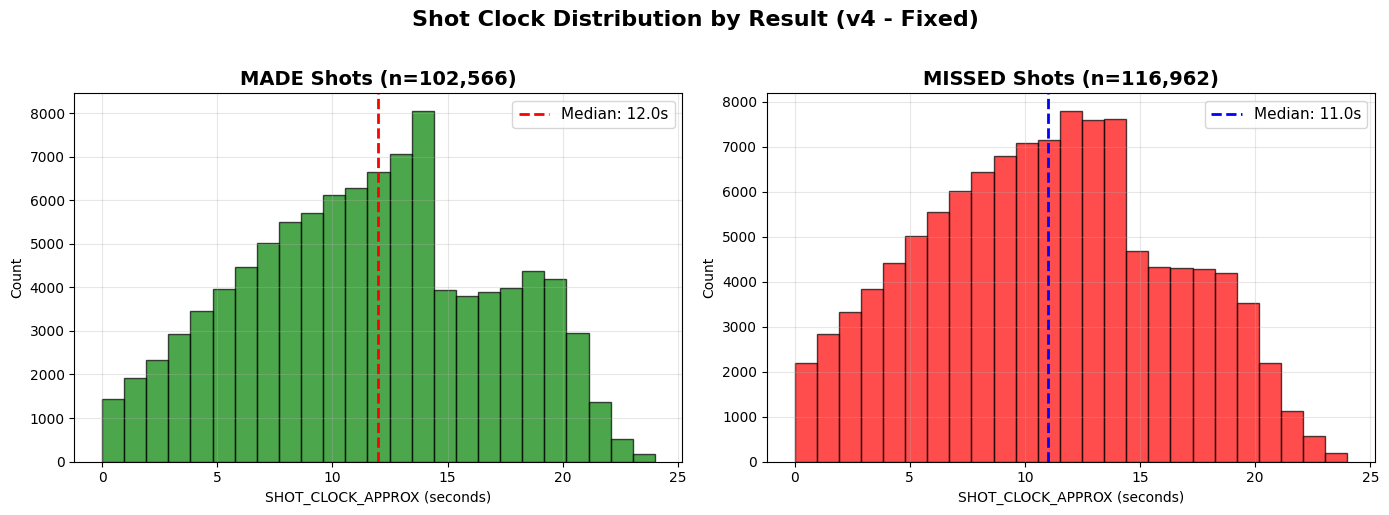


=== Summary Statistics ===
MADE shots   - Median: 12.0s, Mean: 11.5s
MISSED shots - Median: 11.0s, Mean: 10.9s

Difference in medians: 1.0s


In [319]:
import matplotlib.pyplot as plt

# Reload data to get latest enriched results
df = pd.read_csv('enriched_data/nbastatsv3_2024_enriched_shots.csv')
made = df[df['shotResult'].str.upper() == 'MADE']
missed = df[df['shotResult'].str.upper() == 'MISSED']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Made shots histogram
axes[0].hist(made['SHOT_CLOCK_APPROX'].dropna(), bins=25, edgecolor='black', color='green', alpha=0.7)
axes[0].set_title(f'MADE Shots (n={len(made):,})', fontsize=14, fontweight='bold')
axes[0].set_xlabel('SHOT_CLOCK_APPROX (seconds)')
axes[0].set_ylabel('Count')
axes[0].axvline(made['SHOT_CLOCK_APPROX'].median(), color='red', linestyle='--', linewidth=2, 
                label=f'Median: {made["SHOT_CLOCK_APPROX"].median():.1f}s')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Missed shots histogram
axes[1].hist(missed['SHOT_CLOCK_APPROX'].dropna(), bins=25, edgecolor='black', color='red', alpha=0.7)
axes[1].set_title(f'MISSED Shots (n={len(missed):,})', fontsize=14, fontweight='bold')
axes[1].set_xlabel('SHOT_CLOCK_APPROX (seconds)')
axes[1].set_ylabel('Count')
axes[1].axvline(missed['SHOT_CLOCK_APPROX'].median(), color='blue', linestyle='--', linewidth=2,
                label=f'Median: {missed["SHOT_CLOCK_APPROX"].median():.1f}s')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Shot Clock Distribution by Result (v4 - Fixed)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print summary stats
print("\n=== Summary Statistics ===")
print(f"MADE shots   - Median: {made['SHOT_CLOCK_APPROX'].median():.1f}s, Mean: {made['SHOT_CLOCK_APPROX'].mean():.1f}s")
print(f"MISSED shots - Median: {missed['SHOT_CLOCK_APPROX'].median():.1f}s, Mean: {missed['SHOT_CLOCK_APPROX'].mean():.1f}s")
print(f"\nDifference in medians: {abs(made['SHOT_CLOCK_APPROX'].median() - missed['SHOT_CLOCK_APPROX'].median()):.1f}s")

In [320]:
# Investigate remaining 0-second shots
zero_shots = df[df['SHOT_CLOCK_APPROX'] <= 1]
print(f"Shots with SHOT_CLOCK_APPROX <= 1 second: {len(zero_shots):,} ({len(zero_shots)/len(df)*100:.1f}%)")
print(f"  Made: {len(zero_shots[zero_shots['shotResult'].str.upper() == 'MADE']):,}")
print(f"  Missed: {len(zero_shots[zero_shots['shotResult'].str.upper() == 'MISSED']):,}")

print("\n=== SHOT_CLOCK_SOURCE for 0-1 second shots ===")
print(zero_shots['SHOT_CLOCK_SOURCE'].value_counts().head(10))

# These are likely legitimate end-of-clock heaves or putbacks
print("\n=== Sample descriptions of 0-1 second shots ===")
print(zero_shots[['description', 'SHOT_CLOCK_APPROX', 'SHOT_CLOCK_SOURCE', 'shotResult']].sample(15).to_string())

Shots with SHOT_CLOCK_APPROX <= 1 second: 8,389 (3.8%)
  Made: 3,349
  Missed: 5,040

=== SHOT_CLOCK_SOURCE for 0-1 second shots ===
SHOT_CLOCK_SOURCE
made_fg(24)             4571
final_ft(24)             823
def_foul_14(14)          750
def_reb(24)              717
off_reb(14)              510
turnover(24)             454
period_start(24)         256
def_violation_14(14)      74
keep_clock(15)            53
jumpball(24)              53
Name: count, dtype: int64

=== Sample descriptions of 0-1 second shots ===
                                                          description  SHOT_CLOCK_APPROX     SHOT_CLOCK_SOURCE shotResult
40899                               MISS L. James 5' Pullup Jump Shot                1.0           off_reb(14)     Missed
61974                                  MISS Mathews 27' 3PT Jump Shot                1.0           made_fg(24)     Missed
139212                                    MISS Hield 4' Driving Layup                1.0           made_fg(24)     Mis

In [321]:
# Diagnose 0-second shots: look for missing teamId/0 events right before the shot
import numpy as np
import pandas as pd
import re

if 'raw' not in globals():
    raw = pd.read_csv('raw_data/nbastatsv3_2024.csv')

# Fallback helper in case _abs_time isn't in scope
if '_abs_time' not in globals():
    def _abs_time(period, clock_iso):
        m = re.match(r"PT(\d+)M(\d+)\.\d+S", str(clock_iso))
        if not m:
            return None
        rem = int(m.group(1)) * 60 + int(m.group(2))
        reg_len = 12 * 60
        ot_len = 5 * 60
        def _period_len_s(p):
            return reg_len if p <= 4 else ot_len
        return sum(_period_len_s(p) for p in range(1, int(period))) + (_period_len_s(int(period)) - rem)

zero_shots = df[df['SHOT_CLOCK_APPROX'] <= 1].copy()
sample = zero_shots.sample(6, random_state=7)
reset_types = {
    'rebound','turnover','violation','jump ball','free throw','made shot','missed shot'
}

for _, shot in sample.iterrows():
    gid = shot['gameId']
    per = shot['period']
    shot_clock = shot['clock']
    shot_t = _abs_time(per, shot_clock)

    g = raw[raw['gameId'] == gid].copy()
    g = g.sort_values(['period', 'actionNumber']).reset_index(drop=True)
    g['ABS_TIME'] = g.apply(lambda r: _abs_time(r['period'], r['clock']), axis=1)

    window = g[(g['period'] == per) & (g['ABS_TIME'].notna()) & (g['ABS_TIME'] >= shot_t - 30) & (g['ABS_TIME'] <= shot_t)]
    missing_team = window[(window['teamId'].isna()) | (window['teamId'] == 0)]
    missing_team = missing_team[missing_team['actionType'].str.lower().isin(reset_types)]

    print('=== Shot ===')
    print(f"gameId={gid} period={per} clock={shot_clock} ABS={shot_t} team={shot.get('teamTricode')} source={shot.get('SHOT_CLOCK_SOURCE')}")
    print(shot.get('description', ''))

    print('--- Events in prior 30s with teamId missing/0 (reset-like) ---')
    if missing_team.empty:
        print('  (none)')
    else:
        cols = ['actionNumber','clock','ABS_TIME','teamTricode','teamId','actionType','subType','description']
        print(missing_team[cols].to_string(index=False, max_colwidth=60))

    print('--- Reset-like events in prior 30s (any team) ---')
    reset_like = window[window['actionType'].str.lower().isin(reset_types)]
    cols = ['actionNumber','clock','ABS_TIME','teamTricode','teamId','actionType','subType','description']
    print(reset_like[cols].tail(10).to_string(index=False, max_colwidth=60))
    print()


=== Shot ===
gameId=22400040 period=1 clock=PT07M12.00S ABS=288 team=NYK source=final_ft(24)
Anunoby Cutting Dunk Shot (2 PTS) (Towns 1 AST)
--- Events in prior 30s with teamId missing/0 (reset-like) ---
  (none)
--- Reset-like events in prior 30s (any team) ---
 actionNumber       clock  ABS_TIME teamTricode     teamId actionType           subType                                     description
           35 PT07M41.00S       259         CHA 1610612766    Rebound           Unknown                    Miller REBOUND (Off:0 Def:1)
           38 PT07M35.00S       265         CHA 1610612766 Free Throw Free Throw 1 of 2                Salaün Free Throw 1 of 2 (4 PTS)
           39 PT07M35.00S       265         CHA 1610612766 Free Throw Free Throw 2 of 2                Salaün Free Throw 2 of 2 (5 PTS)
           40 PT07M12.00S       288         NYK 1610612752  Made Shot Cutting Dunk Shot Anunoby Cutting Dunk Shot (2 PTS) (Towns 1 AST)

=== Shot ===
gameId=22400229 period=4 clock=PT06M09.00S 

In [322]:
# Drill into the window between last reset-like event and 0-1s shots
import numpy as np
import pandas as pd
import re

if 'raw' not in globals():
    raw = pd.read_csv('raw_data/nbastatsv3_2024.csv')

if '_abs_time' not in globals():
    def _abs_time(period, clock_iso):
        m = re.match(r"PT(\d+)M(\d+)\.\d+S", str(clock_iso))
        if not m:
            return None
        rem = int(m.group(1)) * 60 + int(m.group(2))
        reg_len = 12 * 60
        ot_len = 5 * 60
        def _period_len_s(p):
            return reg_len if p <= 4 else ot_len
        return sum(_period_len_s(p) for p in range(1, int(period))) + (_period_len_s(int(period)) - rem)

reset_types = {
    'made shot','missed shot','turnover','rebound','free throw','jump ball','violation'
}
gap_types = {
    'foul','violation','rebound','turnover','free throw','jump ball','timeout'
}

zero_shots = df[df['SHOT_CLOCK_APPROX'] <= 1].copy()
sample = zero_shots.sample(6, random_state=11)

for _, shot in sample.iterrows():
    gid = shot['gameId']
    per = int(shot['period'])
    shot_clock = shot['clock']
    shot_t = _abs_time(per, shot_clock)
    shot_an = shot.get('actionNumber', np.nan)

    g = raw[raw['gameId'] == gid].copy()
    g = g.sort_values(['period', 'actionNumber']).reset_index(drop=True)
    g['ABS_TIME'] = g.apply(lambda r: _abs_time(r['period'], r['clock']), axis=1)
    g['actionType_l'] = g['actionType'].str.lower()

    # Find the last reset-like event before the shot
    before = g[(g['period'] == per) & (g['ABS_TIME'].notna())]
    if pd.notna(shot_an):
        before = before[(before['ABS_TIME'] < shot_t) | ((before['ABS_TIME'] == shot_t) & (before['actionNumber'] < shot_an))]
    else:
        before = before[before['ABS_TIME'] < shot_t]

    last_reset = before[before['actionType_l'].isin(reset_types)].tail(1)
    if last_reset.empty:
        print('=== Shot ===')
        print(f"gameId={gid} period={per} clock={shot_clock} ABS={shot_t} team={shot.get('teamTricode')} source={shot.get('SHOT_CLOCK_SOURCE')}")
        print('No prior reset-like event found')
        print()
        continue

    lr = last_reset.iloc[0]
    lr_time = lr['ABS_TIME']
    lr_an = lr['actionNumber']

    window = g[(g['period'] == per) & (g['ABS_TIME'].notna())]
    window = window[(window['ABS_TIME'] >= lr_time) & (window['ABS_TIME'] <= shot_t)]

    missing_team = window[(window['teamId'].isna()) | (window['teamId'] == 0)]
    missing_team = missing_team[missing_team['actionType_l'].isin(gap_types)]

    print('=== Shot ===')
    print(f"gameId={gid} period={per} clock={shot_clock} ABS={shot_t} team={shot.get('teamTricode')} source={shot.get('SHOT_CLOCK_SOURCE')}")
    print(shot.get('description', ''))

    print('--- Last reset-like event before shot ---')
    print(lr[['actionNumber','clock','ABS_TIME','teamTricode','teamId','actionType','subType','description']].to_string())

    print('--- Events between last reset and shot with missing/0 teamId ---')
    if missing_team.empty:
        print('  (none)')
    else:
        cols = ['actionNumber','clock','ABS_TIME','teamTricode','teamId','actionType','subType','description']
        print(missing_team[cols].to_string(index=False, max_colwidth=60))

    print('--- All reset-like events between last reset and shot ---')
    reset_like = window[window['actionType_l'].isin(reset_types)]
    cols = ['actionNumber','clock','ABS_TIME','teamTricode','teamId','actionType','subType','description']
    print(reset_like[cols].to_string(index=False, max_colwidth=60))
    print()


=== Shot ===
gameId=22401113 period=2 clock=PT01M01.00S ABS=1379 team=MIN source=made_fg(24)
Conley 3PT Jump Shot (6 PTS) (DiVincenzo 2 AST)
--- Last reset-like event before shot ---
actionNumber                                                  298
clock                                                 PT01M25.00S
ABS_TIME                                                     1355
teamTricode                                                   BKN
teamId                                                 1610612751
actionType                                              Made Shot
subType                                      Alley Oop Layup shot
description     Claxton 1' Alley Oop Layup (10 PTS) (Watford 5...
--- Events between last reset and shot with missing/0 teamId ---
  (none)
--- All reset-like events between last reset and shot ---
 actionNumber       clock  ABS_TIME teamTricode     teamId actionType              subType                                         description
          298 

In [323]:
# Sanity checks for stale_reset sources
import numpy as np
import pandas as pd

# Recompute df if needed
if 'df' not in globals():
    df = pd.read_csv('enriched_data/nbastatsv3_2024_enriched_shots.csv')

print('=== SHOT_CLOCK_SOURCE (top 15) ===')
print(df['SHOT_CLOCK_SOURCE'].value_counts().head(15))

stale = df[df['SHOT_CLOCK_SOURCE'].str.contains('stale_reset', na=False)].copy()
print(f"\nStale resets: {len(stale):,} ({len(stale)/len(df)*100:.2f}%)")

if len(stale) > 0:
    print('\n=== Sample stale_reset rows ===')
    cols = ['gameId','period','clock','teamTricode','description','SHOT_CLOCK_SOURCE','shotResult']
    print(stale[cols].sample(min(12, len(stale)), random_state=7).to_string(index=False))


=== SHOT_CLOCK_SOURCE (top 15) ===
SHOT_CLOCK_SOURCE
made_fg(24)             66973
def_reb(24)             63075
turnover(24)            25893
off_reb(14)             25545
final_ft(24)            16477
def_foul_14(14)          5778
stale_reset(24)          5547
period_start(24)         3215
keep_clock(24)           1220
def_violation_14(14)      678
stale_reset(14)           659
jumpball(24)              637
keep_clock(15)            509
keep_clock(17)            502
keep_clock(16)            487
Name: count, dtype: int64

Stale resets: 6,283 (2.86%)

=== Sample stale_reset rows ===
  gameId  period       clock teamTricode                                         description SHOT_CLOCK_SOURCE shotResult
22400202       3 PT09M28.00S         MIL                  MISS Jackson Jr. 26' 3PT Jump Shot   stale_reset(24)     Missed
22401054       2 PT05M22.00S         BKN                    Claxton 3' Driving Layup (7 PTS)   stale_reset(24)       Made
22400403       4 PT09M34.00S         IND   

In [324]:
# Inspect events between last reset and stale_reset shots
import numpy as np
import pandas as pd
import re

if 'raw' not in globals():
    raw = pd.read_csv('raw_data/nbastatsv3_2024.csv')

if '_abs_time' not in globals():
    def _abs_time(period, clock_iso):
        m = re.match(r"PT(\d+)M(\d+)\.\d+S", str(clock_iso))
        if not m:
            return None
        rem = int(m.group(1)) * 60 + int(m.group(2))
        reg_len = 12 * 60
        ot_len = 5 * 60
        def _period_len_s(p):
            return reg_len if p <= 4 else ot_len
        return sum(_period_len_s(p) for p in range(1, int(period))) + (_period_len_s(int(period)) - rem)

stale = df[df['SHOT_CLOCK_SOURCE'].str.contains('stale_reset', na=False)].copy()
sample = stale.sample(min(6, len(stale)), random_state=23)
reset_types = {
    'made shot','missed shot','turnover','rebound','free throw','jump ball','violation','foul'
}

for _, shot in sample.iterrows():
    gid = shot['gameId']
    per = int(shot['period'])
    shot_clock = shot['clock']
    shot_t = _abs_time(per, shot_clock)
    shot_an = shot.get('actionNumber', np.nan)

    g = raw[raw['gameId'] == gid].copy()
    g = g.sort_values(['period', 'actionNumber']).reset_index(drop=True)
    g['ABS_TIME'] = g.apply(lambda r: _abs_time(r['period'], r['clock']), axis=1)
    g['actionType_l'] = g['actionType'].str.lower()

    before = g[(g['period'] == per) & (g['ABS_TIME'].notna())]
    if pd.notna(shot_an):
        before = before[(before['ABS_TIME'] < shot_t) | ((before['ABS_TIME'] == shot_t) & (before['actionNumber'] < shot_an))]
    else:
        before = before[before['ABS_TIME'] < shot_t]

    last_reset = before[before['actionType_l'].isin(reset_types)].tail(1)

    print('=== Stale Shot ===')
    print(f"gameId={gid} period={per} clock={shot_clock} ABS={shot_t} team={shot.get('teamTricode')} source={shot.get('SHOT_CLOCK_SOURCE')}")
    print(shot.get('description', ''))

    if last_reset.empty:
        print('No prior reset-like event found')
        print()
        continue

    lr = last_reset.iloc[0]
    lr_time = lr['ABS_TIME']

    window = g[(g['period'] == per) & (g['ABS_TIME'].notna())]
    window = window[(window['ABS_TIME'] >= lr_time) & (window['ABS_TIME'] <= shot_t)]

    print('--- Last reset-like event before shot ---')
    print(lr[['actionNumber','clock','ABS_TIME','teamTricode','teamId','actionType','subType','description']].to_string())

    print('--- Intervening events (foul/violation/rebound/turnover/free throw) ---')
    gap = window[window['actionType_l'].isin(reset_types)]
    cols = ['actionNumber','clock','ABS_TIME','teamTricode','teamId','actionType','subType','description']
    print(gap[cols].to_string(index=False, max_colwidth=60))
    print()


=== Stale Shot ===
gameId=22401031 period=2 clock=PT07M11.00S ABS=1009 team=PHI source=stale_reset(24)
Edwards 24' 3PT Jump Shot (12 PTS) (Butler 1 AST)
--- Last reset-like event before shot ---
actionNumber                                            216
clock                                           PT07M40.00S
ABS_TIME                                                980
teamTricode                                             ATL
teamId                                           1610612737
actionType                                        Made Shot
subType                                           Jump Shot
description     Niang 3PT Jump Shot (12 PTS) (Krejci 1 AST)
--- Intervening events (foul/violation/rebound/turnover/free throw) ---
 actionNumber       clock  ABS_TIME teamTricode     teamId actionType   subType                                       description
          216 PT07M40.00S       980         ATL 1610612737  Made Shot Jump Shot       Niang 3PT Jump Shot (12 PTS) (Krejci 